# Is Hier-COS inference itself the main advantage?

This notebook performs an inference-only, paired comparison on existing checkpoints. No model is retrained.

Every inference rule is one cell of a **readout × transform** grid, and the same four cells are evaluated for every model:

| | `node_score` | `subspace_norm` |
|---|---|---|
| **no transform** | rank each node by its own coordinate | rank it by the L2 norm over its ancestors+self+descendants subspace |

`subspace_norm` aggregates each model's **own per-level probabilities**, not raw logits, because an L2 norm is not invariant to a monotone map — `‖f(z)‖` is not a monotone function of `‖z‖`. Softmax for H-CAST and HT-CapsNet, sigmoid/sigmoid/softmax for HRN, and identity for Hier-COS, whose training already drives non-target coordinate magnitudes to ~0. `node_score` is unaffected, since every one of those activations is monotone and cannot change a per-level argmax. Set `SUBSPACE_SCORE_SPACE = 'coordinate'` to reproduce raw-logit results.
| **HCC projection** | `hcc_node_score` | `hcc_subspace_norm` |

Each checkpoint's own inference is one of these cells — `node_score` for H-CAST, HT-CapsNet, and HRN, `subspace_norm` for Hier-COS — so the comparison asks one question of every model: **does aggregating over the taxonomy subspace, or projecting onto the hierarchy constraint, beat what the model already does?**

The key quantity is the within-checkpoint **gain against that model's native cell**. Positive always means the listed cell is better, including for lower-is-better AHD and TICE. Absolute cross-model scores are secondary because architectures and training objectives differ. Every completed seed is evaluated separately; its YAML stays in that seed's run directory, and tables/plots report mean ± sample standard deviation with the seed count.

Use the **WHAT TO SHOW** cell to pick which inference cells, decoder (independent, top-down, or both), datasets, models, and metrics to display. Everything below reads that selection, so no reload is needed to change the view.

## Experimental cautions

1. H-CAST/HT-CapsNet/HRN coordinates were not trained as Hier-COS coordinates; identity-frame decoding is a post-hoc assumption.
2. The available best checkpoints were selected using each model's native validation inference. This can favor native inference.
3. Top-down and independent rows must use their corresponding best checkpoints. This notebook preserves that rule.
4. Unequal seed coverage must be reported. A one-seed sign is suggestive, not robust evidence.
5. Treat this test-set analysis as a pre-specified ablation. Do not tune normalization or score variants repeatedly on test data.

In [15]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import torch
import yaml

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'evaluation').is_dir():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'evaluation').is_dir(), 'Run this notebook from the repository or notebooks directory.'

NOTEBOOK_UTILS = str(REPO_ROOT / 'notebooks' / 'utils')
if NOTEBOOK_UTILS not in sys.path:
    sys.path.insert(0, NOTEBOOK_UTILS)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from multiseed_utils import discover_seed_dirs, sample_stats

OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
DATASETS = ('cifar100', 'cub200', 'aircraft')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cpu':
    print('CUDA is unavailable; inference will run on CPU and may be slow.')
RUN_EVALUATION = True  # The next execution cell runs the Python checkpoint evaluator.
OVERWRITE = False
# 'all' evaluates the four readout x transform cells; 'both' only the two
# untransformed readouts. Existing YAMLs are reused as they are, so set
# OVERWRITE=True to regenerate older two-cell files with all four.
INFERENCE_MODE = 'all'
# Space `subspace_norm` aggregates. An L2 norm is not invariant to a monotone map,
# so unlike node_score this readout depends on it. 'probability' maps each level
# through its own head's activation first (softmax for H-CAST, sigmoid/sigmoid/
# softmax for HRN, identity for Hier-COS, whose training already pins non-target
# coordinate magnitudes near zero). 'coordinate' norms the raw logits and
# reproduces the behaviour of results generated before this option existed.
SUBSPACE_SCORE_SPACE = 'probability'

BASELINE_ROOTS = {
    'cifar100': {
        'hcast': OUTPUTS_ROOT / 'hcast_cifar100',
        'htcapsnet': OUTPUTS_ROOT / 'capsnet_cifar100',
        'hrn': OUTPUTS_ROOT / 'hrn_cifar100',
        'hiercos': OUTPUTS_ROOT / 'hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf',
    },
    'cub200': {
        'hcast': OUTPUTS_ROOT / 'hcast_cub200',
        'htcapsnet': OUTPUTS_ROOT / 'capsnet_cub200',
        'hrn': OUTPUTS_ROOT / 'hrn_cub200',
        'hiercos': OUTPUTS_ROOT / 'hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf',
    },
    'aircraft': {
        'hcast': OUTPUTS_ROOT / 'hcast_aircraft',
        'htcapsnet': OUTPUTS_ROOT / 'capsnet_aircraft',
        'hrn': OUTPUTS_ROOT / 'hrn_aircraft',
        'hiercos': OUTPUTS_ROOT / 'hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf',
    },
}

BASELINE_ROOTS

{'cifar100': {'hcast': PosixPath('/scratch/g.saggini1/outputs/hcast_cifar100'),
  'htcapsnet': PosixPath('/scratch/g.saggini1/outputs/capsnet_cifar100'),
  'hrn': PosixPath('/scratch/g.saggini1/outputs/hrn_cifar100'),
  'hiercos': PosixPath('/scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf')},
 'cub200': {'hcast': PosixPath('/scratch/g.saggini1/outputs/hcast_cub200'),
  'htcapsnet': PosixPath('/scratch/g.saggini1/outputs/capsnet_cub200'),
  'hrn': PosixPath('/scratch/g.saggini1/outputs/hrn_cub200'),
  'hiercos': PosixPath('/scratch/g.saggini1/outputs/hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf')},
 'aircraft': {'hcast': PosixPath('/scratch/g.saggini1/outputs/hcast_aircraft'),
  'htcapsnet': PosixPath('/scratch/g.saggini1/outputs/capsnet_aircraft'),
  'hrn': PosixPath('/scratch/g.saggini1/outputs/hrn_aircraft'),
  'hiercos': PosixPath('/scratch/g.saggini1/outputs/hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf')}}

In [16]:
def completed_seed_dirs(root: Path):
    seed_dirs = discover_seed_dirs(root, require_log=False, require_config=True)
    candidates = seed_dirs or ([root] if root.is_dir() else [])
    required = ('config_resolved.yaml', 'best_topdown.pt', 'best_independent.pt')
    return [path for path in candidates if all((path / name).is_file() for name in required)]

run_dirs = {
    dataset: {model: completed_seed_dirs(root) for model, root in BASELINE_ROOTS[dataset].items()}
    for dataset in DATASETS
}
coverage = pd.DataFrame(
    [
        {'dataset': dataset, 'model': model, 'runs': len(paths), 'paths': [str(path) for path in paths]}
        for dataset, model_runs in run_dirs.items()
        for model, paths in model_runs.items()
    ]
)
display(coverage)
missing_baselines = coverage.loc[coverage['runs'].eq(0), ['dataset', 'model']]
if not missing_baselines.empty:
    print('Missing completed baselines:')
    display(missing_baselines)
    print('Edit BASELINE_ROOTS or finish those runs before making a full four-model claim.')

,dataset,model,runs,paths
0,cifar100,hcast,3,[/scratch/g.saggini1/outputs/hcast_cifar100/se...
1,cifar100,htcapsnet,3,[/scratch/g.saggini1/outputs/capsnet_cifar100/...
2,cifar100,hrn,3,[/scratch/g.saggini1/outputs/hrn_cifar100/seed...
3,cifar100,hiercos,3,[/scratch/g.saggini1/outputs/hiercos_cifar100_...
4,cub200,hcast,3,[/scratch/g.saggini1/outputs/hcast_cub200/seed...
5,cub200,htcapsnet,3,[/scratch/g.saggini1/outputs/capsnet_cub200/se...
6,cub200,hrn,3,[/scratch/g.saggini1/outputs/hrn_cub200/seed_0...
7,cub200,hiercos,3,[/scratch/g.saggini1/outputs/hiercos_cub200_gl...
8,aircraft,hcast,3,[/scratch/g.saggini1/outputs/hcast_aircraft/se...
9,aircraft,htcapsnet,3,[/scratch/g.saggini1/outputs/capsnet_aircraft/...


In [17]:
# Run this cell from one kernel at a time. The evaluator checks for an existing
# output before it starts and again when it saves, so a second concurrent copy
# of the sweep makes whichever process is slower fail at save time.
result_files = []
failed_runs = []
for dataset, model_runs in run_dirs.items():
    for model, paths in model_runs.items():
        for run_dir in paths:
            output_path = run_dir / 'posthoc_inference_test_metrics.yaml'
            result_files.append(output_path)
            if not RUN_EVALUATION:
                continue
            if output_path.exists() and not OVERWRITE:
                print('[reuse]', output_path)
                continue
            command = [
                sys.executable, '-m', 'evaluation.evaluate_checkpoints',
                '--run-dir', str(run_dir),
                '--inference-mode', INFERENCE_MODE,
                '--subspace-score-space', SUBSPACE_SCORE_SPACE,
                '--checkpoint-mode', 'both',
                '--device', DEVICE,
            ]
            if OVERWRITE:
                command.append('--overwrite')
            print('[run]', ' '.join(command))
            # The evaluator writes its YAML only at the end, so one unevaluable
            # run leaves every already-written file intact. Keep going and
            # report the failures below rather than discarding the sweep.
            try:
                subprocess.run(command, cwd=REPO_ROOT, check=True)
            except subprocess.CalledProcessError as error:
                print(f'[failed] exit status {error.returncode}: {run_dir}')
                failed_runs.append((run_dir, error.returncode))

available_result_files = [path for path in result_files if path.is_file()]
print(f'Available result files: {len(available_result_files)}/{len(result_files)}')
if not RUN_EVALUATION and not available_result_files:
    print('Set RUN_EVALUATION=True and run this cell to generate results.')

if failed_runs:
    print(f'\n[error] {len(failed_runs)} run(s) did not produce a result file. '
          'The rows below are missing from every table in this notebook:')
    for run_dir, returncode in failed_runs:
        print(f'    exit {returncode}  {run_dir}')

# Files written before the four-cell grid existed hold only two inference rows.
# They are still readable — the loader maps their names onto the grid — but the
# missing cells simply will not be selectable until they are regenerated.
partial = []
fallback = []
other_space = []
for path in available_result_files:
    payload = yaml.safe_load(path.read_text())
    if len(payload.get('resolved_inference_modes', [])) < 4:
        partial.append(path)
    if payload.get('test_split_source') == 'official_dataset_adapter_fallback':
        fallback.append(path)
    # Absent key = written before the option existed, i.e. the coordinate space.
    if payload.get('subspace_score_space', 'coordinate') != SUBSPACE_SCORE_SPACE:
        other_space.append(path)
if partial:
    print(f'\n{len(partial)}/{len(available_result_files)} files predate the four-cell grid '
          f'or were written with --inference-mode both.')
    print('Set OVERWRITE=True and re-run this cell to fill in the missing cells.')
if other_space:
    print(f'\n{len(other_space)}/{len(available_result_files)} files were written in a '
          f'different subspace score space than the selected {SUBSPACE_SCORE_SPACE!r}.')
    print('Their subspace_norm rows are not comparable with the rest. Set '
          'OVERWRITE=True and re-run this cell to regenerate them.')

if fallback:
    print(f'\n[warning] {len(fallback)} file(s) were evaluated with the official-adapter '
          'fallback because the run\'s configured test manifest is missing. Their label '
          'space may differ from what the run trained on; check the native row against '
          'the run\'s own test_metrics.yaml before trusting them:')
    for path in fallback:
        print('   ', path)

[reuse] /scratch/g.saggini1/outputs/hcast_cifar100/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cifar100/seed_1/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cifar100/seed_2/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/capsnet_cifar100/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/capsnet_cifar100/seed_1/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/capsnet_cifar100/seed_2/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hrn_cifar100/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hrn_cifar100/seed_1/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hrn_cifar100/seed_2/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.

In [18]:
from evaluation.evaluate_checkpoints import canonical_inference_rule, native_inference_rule

DECODERS = ('independent', 'topdown')


def split_metric(metric):
    """Return (metric_family, decoder) for one metric key, or (None, None)."""
    for decoder in DECODERS:
        if metric.startswith(f'acc_level_{decoder}_'):
            return f"acc_level_{metric.rsplit('_', 1)[-1]}", decoder
        if metric.endswith(f'_{decoder}'):
            return metric[: -(len(decoder) + 1)], decoder
    return None, None


def native_cell_of(payload):
    """The grid cell that reproduces this checkpoint's own inference."""
    return payload.get('native_inference_mode') or native_inference_rule(
        payload['model'], bool(payload.get('hcc_trained_run', False))
    )


def canonical_cell(row_name, payload):
    """Map one YAML row onto a grid cell, for files written before or after the rename.

    `normal` named whatever the checkpoint did natively, so it follows the model;
    every other legacy name maps through the CLI's own alias table.
    """
    if row_name == 'normal':
        return native_cell_of(payload)
    return canonical_inference_rule(row_name, payload['model'])


# Every decoder is loaded. Selection happens in the next cell, so switching
# between independent, top-down, or both never needs a reload.
records = []
for result_path in available_result_files:
    payload = yaml.safe_load(result_path.read_text())
    native_cell = native_cell_of(payload)
    for checkpoint_mode, checkpoint_payload in payload['checkpoints'].items():
        for row_name, metrics in checkpoint_payload['inference'].items():
            inference = canonical_cell(row_name, payload)
            for metric, value in metrics.items():
                metric_family, decoder = split_metric(metric)
                if metric_family is None:
                    continue
                records.append({
                    'dataset': payload['dataset'],
                    'model': payload['model'],
                    'seed': int(payload['seed']),
                    'checkpoint_mode': checkpoint_mode,
                    'decoder': decoder,
                    'inference': inference,
                    'is_native': inference == native_cell,
                    'metric_family': metric_family,
                    'metric': metric,
                    'value': float(value),
                })

results_long = pd.DataFrame(records)
if results_long.empty:
    print('No result rows loaded yet.')
else:
    coverage_cells = (
        results_long.groupby(['dataset', 'model'])['inference']
        .agg(lambda values: ', '.join(sorted(set(values))))
        .reset_index()
        .rename(columns={'inference': 'available inference cells'})
    )
    print('Loaded rows:', len(results_long))
    display(coverage_cells)

Loaded rows: 4032


,dataset,model,available inference cells
0,cifar-100,hcast,"hcc_node_score, hcc_subspace_norm, node_score,..."
1,cifar-100,hiercos,"hcc_node_score, hcc_subspace_norm, node_score,..."
2,cifar-100,hrn,"hcc_node_score, hcc_subspace_norm, node_score,..."
3,cifar-100,ht_capsnet,"hcc_node_score, hcc_subspace_norm, node_score,..."
4,cub-200-2011,hcast,"hcc_node_score, hcc_subspace_norm, node_score,..."
5,cub-200-2011,hiercos,"hcc_node_score, hcc_subspace_norm, node_score,..."
6,cub-200-2011,hrn,"hcc_node_score, hcc_subspace_norm, node_score,..."
7,cub-200-2011,ht_capsnet,"hcc_node_score, hcc_subspace_norm, node_score,..."
8,fgvc-aircraft,hcast,"hcc_node_score, hcc_subspace_norm, node_score,..."
9,fgvc-aircraft,hiercos,"hcc_node_score, hcc_subspace_norm, node_score,..."


In [19]:
# =====================  WHAT TO SHOW  =====================================
# Edit these, then re-run this cell and the ones below.
SHOW_INFERENCES = 'all'      # 'all' | 'native' | e.g. ['node_score', 'hcc_node_score']
SHOW_DECODERS = 'both'       # 'both' | 'independent' | 'topdown'
SHOW_DATASETS = 'all'        # 'all' | e.g. ['cifar-100', 'fgvc-aircraft']
SHOW_MODELS = 'all'          # 'all' | e.g. ['hcast', 'hiercos']
SHOW_METRICS = ('fpa', 'weighted_ap', 'tice', 'ahd')   # add 'acc_level_0', 'acc_level_1', ...
MATCHED_CHECKPOINT = True    # repo rule: read each decoder from its own selected checkpoint
# ==========================================================================

INFERENCE_ORDER = ('node_score', 'subspace_norm', 'hcc_node_score', 'hcc_subspace_norm')
INFERENCE_LABELS = {
    'node_score': 'node_score',
    'subspace_norm': 'subspace_norm',
    'hcc_node_score': 'hcc + node_score',
    'hcc_subspace_norm': 'hcc + subspace_norm',
}
INFERENCE_COLORS = {
    'node_score': '#2563eb',
    'subspace_norm': '#16a34a',
    'hcc_node_score': '#d97706',
    'hcc_subspace_norm': '#7c3aed',
}
DECODER_LABELS = {'independent': 'Independent', 'topdown': 'Top-down'}


def _as_list(value, available):
    """Normalize a selector into a concrete list of values that exist in the data."""
    if value is None or (isinstance(value, str) and value == 'all'):
        return list(available)
    if isinstance(value, str):
        value = [value]
    unknown = [item for item in value if item not in available]
    if unknown:
        print(f'[note] not present in the loaded data, ignored: {unknown}')
    return [item for item in value if item in available]


def select(
    frame=None,
    inferences=None,
    decoders=None,
    datasets=None,
    models=None,
    metrics=None,
    matched_checkpoint=None,
):
    """Return the subset of rows to display.

    Defaults come from the SHOW_* settings above, so `select()` gives the current
    view and `select(decoders='topdown', inferences=['subspace_norm'])` answers a
    one-off question without touching them.

    `matched_checkpoint=True` keeps the repository rule that a decoder is read
    from its own validation-selected checkpoint. Setting it False also shows the
    crossed combinations, which are not comparable to the reported results.
    """
    frame = results_long if frame is None else frame
    if frame.empty:
        return frame

    inferences = SHOW_INFERENCES if inferences is None else inferences
    decoders = SHOW_DECODERS if decoders is None else decoders
    datasets = SHOW_DATASETS if datasets is None else datasets
    models = SHOW_MODELS if models is None else models
    metrics = SHOW_METRICS if metrics is None else metrics
    matched = MATCHED_CHECKPOINT if matched_checkpoint is None else matched_checkpoint

    selected = frame
    if isinstance(inferences, str) and inferences == 'native':
        selected = selected[selected['is_native']]
    else:
        available = [cell for cell in INFERENCE_ORDER if cell in set(frame['inference'])]
        selected = selected[selected['inference'].isin(_as_list(inferences, available))]

    decoders = ['independent', 'topdown'] if decoders == 'both' else decoders
    selected = selected[selected['decoder'].isin(_as_list(decoders, DECODERS))]
    selected = selected[selected['dataset'].isin(_as_list(datasets, sorted(set(frame['dataset']))))]
    selected = selected[selected['model'].isin(_as_list(models, sorted(set(frame['model']))))]
    selected = selected[
        selected['metric_family'].isin(_as_list(metrics, sorted(set(frame['metric_family']))))
    ]
    if matched:
        selected = selected[selected['decoder'].eq(selected['checkpoint_mode'])]
    return selected.reset_index(drop=True)


view = select()
if view.empty:
    print('Nothing selected. Widen the SHOW_* settings above.')
else:
    print(f'Selected {len(view)} rows')
    print('  inference cells :', ', '.join(c for c in INFERENCE_ORDER if c in set(view['inference'])))
    print('  decoders        :', ', '.join(sorted(set(view['decoder']))))
    print('  datasets        :', ', '.join(sorted(set(view['dataset']))))
    print('  models          :', ', '.join(sorted(set(view['model']))))
    print('  metrics         :', ', '.join(sorted(set(view['metric_family']))))
    print('  checkpoint rule :', 'matched to decoder' if MATCHED_CHECKPOINT else 'ALL (includes crossed pairs)')
    display(view.head())

Selected 1152 rows
  inference cells : node_score, subspace_norm, hcc_node_score, hcc_subspace_norm
  decoders        : independent, topdown
  datasets        : cifar-100, cub-200-2011, fgvc-aircraft
  models          : hcast, hiercos, hrn, ht_capsnet
  metrics         : ahd, fpa, tice, weighted_ap
  checkpoint rule : matched to decoder


,dataset,model,seed,checkpoint_mode,decoder,inference,is_native,metric_family,metric,value
0,cifar-100,hcast,0,topdown,topdown,node_score,True,weighted_ap,weighted_ap_topdown,0.777372
1,cifar-100,hcast,0,topdown,topdown,node_score,True,ahd,ahd_topdown,0.486900
2,cifar-100,hcast,0,topdown,topdown,node_score,True,tice,tice_topdown,0.000000
3,cifar-100,hcast,0,topdown,topdown,node_score,True,fpa,fpa_topdown,0.751900
4,cifar-100,hcast,0,topdown,topdown,subspace_norm,False,weighted_ap,weighted_ap_topdown,0.779731


In [20]:
LOWER_IS_BETTER = ('tice', 'ahd')
PAIR_KEYS = ['dataset', 'model', 'seed', 'checkpoint_mode', 'decoder', 'metric_family', 'metric']


def display_value(frame, column='value'):
    """AHD stays in raw units; every other metric is a percentage."""
    return np.where(frame['metric_family'].eq('ahd'), frame[column], 100.0 * frame[column])


def summarize_samples(frame, group_columns, value_column, mean_column, std_column):
    rows = []
    for keys, group in frame.groupby(group_columns, dropna=False):
        keys = keys if isinstance(keys, tuple) else (keys,)
        mean, std, count = sample_stats(group[value_column].tolist())
        rows.append({
            **dict(zip(group_columns, keys)),
            mean_column: mean,
            std_column: std,
            'seeds': count,
        })
    return pd.DataFrame(rows)


def paired_gains(frame=None, reference=None):
    """Gain of each selected cell against the same checkpoint's native cell.

    Positive always means the selected cell is better, including for the
    lower-is-better AHD and TICE. The native row is taken from the full loaded
    table, so deselecting it does not remove the reference.
    """
    frame = view if frame is None else frame
    reference = results_long if reference is None else reference
    if frame.empty or reference.empty:
        return pd.DataFrame()

    native = (
        reference[reference['is_native']][PAIR_KEYS + ['value', 'inference']]
        .rename(columns={'value': 'native_value', 'inference': 'native_inference'})
    )
    merged = frame[~frame['is_native']].merge(native, on=PAIR_KEYS, how='inner')
    if merged.empty:
        return merged
    sign = np.where(merged['metric_family'].isin(LOWER_IS_BETTER), -1.0, 1.0)
    merged['gain'] = sign * (merged['value'] - merged['native_value'])
    merged['gain_display'] = np.where(
        merged['metric_family'].eq('ahd'), merged['gain'], 100.0 * merged['gain']
    )
    return merged


if not view.empty:
    view = view.copy()
    view['value_display'] = display_value(view)
    absolute_summary = summarize_samples(
        view,
        ['dataset', 'model', 'decoder', 'inference', 'is_native', 'metric_family'],
        'value_display',
        'mean_value',
        'std_value',
    )
    print('Absolute results (mean, sample standard deviation, seed count):')
    display(absolute_summary)

    paired = paired_gains()
    if paired.empty:
        print('\nNo paired gains: only the native cell is selected, or its row is missing.')
        gain_summary = pd.DataFrame()
    else:
        gain_summary = summarize_samples(
            paired,
            ['dataset', 'model', 'decoder', 'inference', 'metric_family'],
            'gain_display',
            'mean_gain',
            'std_gain',
        )
        native_names = ', '.join(sorted(set(paired['native_inference'])))
        print(f'\nPaired gains against each checkpoint\'s native cell ({native_names}).')
        print('Positive favors the listed cell, for every metric.')
        display(gain_summary)
else:
    absolute_summary = pd.DataFrame()
    paired = pd.DataFrame()
    gain_summary = pd.DataFrame()

Absolute results (mean, sample standard deviation, seed count):


,dataset,model,decoder,inference,is_native,metric_family,mean_value,std_value,seeds
0,cifar-100,hcast,independent,hcc_node_score,False,ahd,0.531000,0.009762,3
1,cifar-100,hcast,independent,hcc_node_score,False,fpa,71.910000,0.281603,3
2,cifar-100,hcast,independent,hcc_node_score,False,tice,11.853333,0.342394,3
3,cifar-100,hcast,independent,hcc_node_score,False,weighted_ap,77.514271,0.266591,3
4,cifar-100,hcast,independent,hcc_subspace_norm,False,ahd,0.489100,0.009054,3
...,...,...,...,...,...,...,...,...,...
379,fgvc-aircraft,ht_capsnet,topdown,node_score,True,weighted_ap,7.993299,1.372581,3
380,fgvc-aircraft,ht_capsnet,topdown,subspace_norm,False,ahd,2.687169,0.003605,3
381,fgvc-aircraft,ht_capsnet,topdown,subspace_norm,False,fpa,1.280128,0.317994,3
382,fgvc-aircraft,ht_capsnet,topdown,subspace_norm,False,tice,0.000000,0.000000,3



Paired gains against each checkpoint's native cell (node_score, subspace_norm).
Positive favors the listed cell, for every metric.


,dataset,model,decoder,inference,metric_family,mean_gain,std_gain,seeds
0,cifar-100,hcast,independent,hcc_node_score,ahd,-0.020267,0.001528,3
1,cifar-100,hcast,independent,hcc_node_score,fpa,-1.566667,0.142244,3
2,cifar-100,hcast,independent,hcc_node_score,tice,-4.240000,0.050000,3
3,cifar-100,hcast,independent,hcc_node_score,weighted_ap,-0.800521,0.161946,3
4,cifar-100,hcast,independent,hcc_subspace_norm,ahd,0.021633,0.001401,3
...,...,...,...,...,...,...,...,...
283,fgvc-aircraft,ht_capsnet,topdown,hcc_subspace_norm,weighted_ap,-1.243124,1.399194,3
284,fgvc-aircraft,ht_capsnet,topdown,subspace_norm,ahd,-0.045905,0.048389,3
285,fgvc-aircraft,ht_capsnet,topdown,subspace_norm,fpa,-1.000100,0.981577,3
286,fgvc-aircraft,ht_capsnet,topdown,subspace_norm,tice,0.000000,0.000000,3


## How to read the four figures

All four figures are drawn at their printed size (`TEXT_WIDTH_IN`, default 6.3 in) and saved as
PDF for LaTeX plus PNG for previews, and each prints a `figure` environment to paste into
the thesis. With `THESIS_STYLE = True` the title and the explanatory paragraph are left out
of the image, because in a thesis they belong to the caption; set it to `False` to get them
back inside the figure.

**Effect grid.** One tile per (dataset, model) x (inference cell, decoder), coloured by the
gain against that model's *own* native readout, sign-adjusted so **positive always means
better** — including for the lower-is-better TICE and AHD. The colour scale is
symmetric-log: without it the +1 pp effects that matter for H-CAST and Hier-COS are
invisible next to the ~-33 pp collapse of Hier-COS under `hcc + node`. Read colour for the
pattern, the printed number for the value. `native` marks each model's own cell (gain 0 by
definition) and `†` marks an effect whose sign is not the same in all seeds. A decoder block
that is zero for structural rather than empirical reasons is not drawn at all — the omission
is stated in one line under the panel, and the space goes to the columns that carry a result.

**Accuracy-consistency map.** TICE (x, log scale, lower is better) against FPA (y, higher is
better) for independent decoding only — top-down decoding is consistent by construction, so
its TICE is identically 0 and the trade-off would be degenerate. The three panels share both
axes, so they are directly comparable. Arrows start at the native cell, so the arrowhead
direction is the result: **left** = buys consistency, **up** = buys accuracy, **up-and-left**
= free win, **down** = an accuracy loss. This is the figure that shows the central finding —
`subspace_norm` moves H-CAST and HRN sharply left *and* upwards, while every `hcc_` cell
sends Hier-COS down and to the right.

**Decoder gain, one figure per readout.** The last two figures ask what top-down decoding is
still worth once the readout is fixed, one figure for `node_score` and one for
`subspace_norm`. Each bar is the **relative** change

$$100 \cdot \frac{\mathrm{FPA}_{\text{top-down}} - \mathrm{FPA}_{\text{independent}}}{\mathrm{FPA}_{\text{independent}}},$$

formed per seed and only then averaged, so a `+5%` bar means 5% more full paths are correct,
not 5 pp — that keeps models at very different absolute accuracy on one scale. Blue is a gain
for top-down decoding, red a loss, error bars are the sample SD of the paired per-seed effect,
and `†` again marks an effect whose sign is not the same in all seeds. Both figures share one
horizontal range, so bar lengths can be compared across them; that is the comparison to read,
because it is what separates "top-down decoding is doing the work" from "the readout already
is". A relative change is a ratio, so it explodes when the denominator collapses: a run whose
independent-decoding FPA is below `MIN_BASELINE_FPA` (5%) neither sets the axis nor gets an
error bar, is drawn to the axis edge with an arrow, and is listed with its baseline under the
axis — HT-CapsNet on FGVC-Aircraft moves 0.8% to 2.3% FPA and so scores +220%. The table
printed above the figures also gives the absolute means and the paired difference in
percentage points. TICE is omitted because it is identically zero under top-down decoding, so
its decoder difference is structural rather than empirical. As everywhere else, each decoder
is read from its own validation-selected checkpoint.

[note] 12 columns need 6.40 in; at width=\textwidth LaTeX scales it to 98% (tile labels land at 6.7 pt). Show fewer metrics, or place it on a landscape page.
[saved] /scratch/g.saggini1/outputs/analysis/posthoc_hiercos_inference_comparison/effect_grid.pdf
[saved] /scratch/g.saggini1/outputs/analysis/posthoc_hiercos_inference_comparison/effect_grid.png


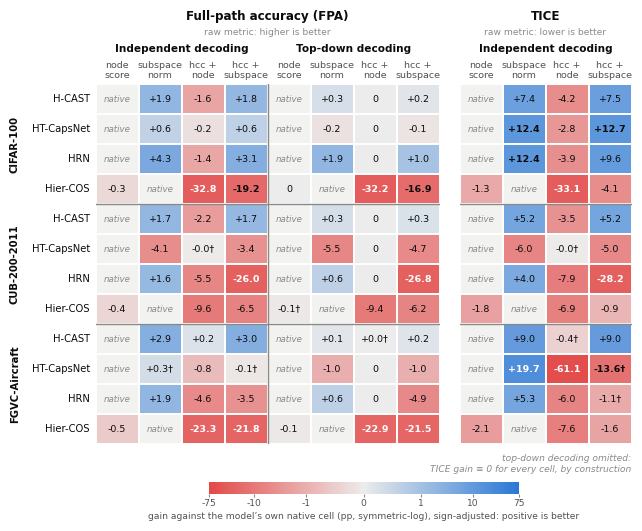


% ---- LaTeX ----------------------------------------------------
\begin{figure}[tbp]
  \centering
  \includegraphics[width=\textwidth]{figures/effect_grid}
  \caption{Post-hoc inference grid. Each tile is the mean gain over 3 seeds of one readout$\times$transform cell against the same checkpoint's own native readout, sign-adjusted so that positive always means better, including for the lower-is-better TICE. Colour is symmetric-log with a linear region of $\pm1$~pp, so a $1$~pp effect stays visible next to a $30$~pp collapse; read the printed numbers for exact values. \emph{native} marks each model's own cell, which is $0$ by definition, and $\dagger$ marks an effect whose sign is not the same for every seed. Each decoder is read from its own validation-selected checkpoint.}
  \label{fig:posthoc-effect-grid}
\end{figure}
[saved] /scratch/g.saggini1/outputs/analysis/posthoc_hiercos_inference_comparison/accuracy_consistency_map.pdf
[saved] /scratch/g.saggini1/outputs/analysis/posthoc_hi

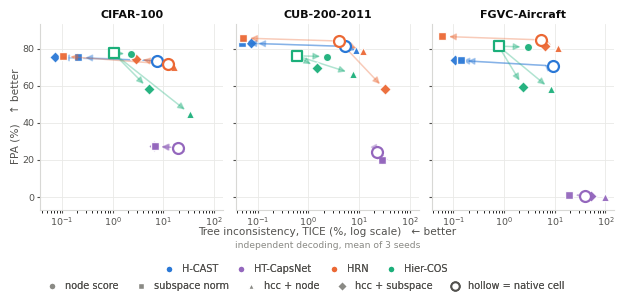


% ---- LaTeX ----------------------------------------------------
\begin{figure}[tbp]
  \centering
  \includegraphics[width=\textwidth]{figures/accuracy_consistency_map}
  \caption{What each inference cell trades. Absolute test TICE (horizontal, log scale, lower is better) against full-path accuracy (vertical, higher is better) under independent decoding, averaged over 3 seeds. Each arrow starts at the model's own native readout (hollow marker) and ends at one alternative cell, so up-and-left is a free win, straight left buys consistency at no accuracy cost, and downward movement is an accuracy loss. Top-down decoding is omitted because it is consistent by construction (TICE $\equiv 0$); TICE values below 0.05\% are clamped to the axis floor so that they remain visible on the log scale.}
  \label{fig:posthoc-accuracy-consistency}
\end{figure}
Relative gain of top-down over independent decoding (test FPA; per-seed 100·(td−ind)/ind, mean ± sample SD):


,dataset,model,readout,independent FPA %,independent SD,top-down FPA %,top-down − independent (pp),relative gain %,relative SD,seeds,same sign in every seed,weak_baseline
0,cifar-100,hcast,node_score,73.477,0.187,75.010,1.533,2.088,0.496,3,True,False
1,cifar-100,ht_capsnet,node_score,26.663,18.276,27.673,1.010,6.998,7.025,3,True,False
2,cifar-100,hrn,node_score,71.667,0.386,74.167,2.500,3.490,0.400,3,True,False
3,cifar-100,hiercos,node_score,77.213,0.132,77.737,0.523,0.678,0.073,3,True,False
4,cub-200-2011,hcast,node_score,81.268,0.329,82.683,1.415,1.742,0.327,3,True,False
5,cub-200-2011,ht_capsnet,node_score,24.140,0.414,26.021,1.881,7.779,1.241,3,True,False
6,cub-200-2011,hrn,node_score,84.150,0.370,85.030,0.880,1.047,0.408,3,True,False
7,cub-200-2011,hiercos,node_score,75.785,0.458,76.130,0.345,0.455,0.080,3,True,False
8,fgvc-aircraft,hcast,node_score,70.727,1.035,73.467,2.740,3.879,0.841,3,True,False
9,fgvc-aircraft,ht_capsnet,node_score,0.790,0.255,2.280,1.490,220.242,208.334,3,True,True


[saved] /scratch/g.saggini1/outputs/analysis/posthoc_hiercos_inference_comparison/decoder_gain_node_score.pdf
[saved] /scratch/g.saggini1/outputs/analysis/posthoc_hiercos_inference_comparison/decoder_gain_node_score.png


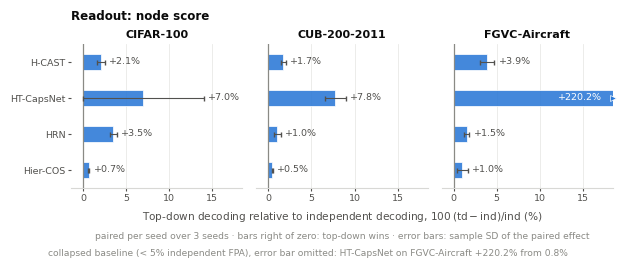


% ---- LaTeX ----------------------------------------------------
\begin{figure}[tbp]
  \centering
  \includegraphics[width=\textwidth]{figures/decoder_gain_node_score}
  \caption{Relative gain of top-down over independent decoding under the untransformed node score readout. Each bar is $100\,(\mathrm{FPA}_{\text{top-down}} - \mathrm{FPA}_{\text{independent}}) / \mathrm{FPA}_{\text{independent}}$, formed per seed and then averaged over 3 seeds; error bars are the sample standard deviation of that paired per-seed effect and $\dagger$ marks an effect whose sign is not the same for every seed. The quantity is a relative change, not a percentage-point difference, so the same bar length means the same fraction of full paths recovered at every absolute accuracy level. The two readout figures share one horizontal range and are directly comparable. Each decoder is read from its own validation-selected checkpoint. TICE is not shown because top-down decoding makes it identically zero by constru

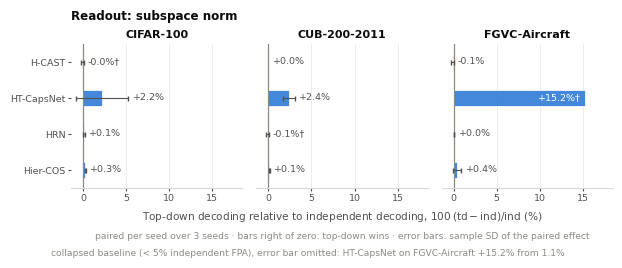


% ---- LaTeX ----------------------------------------------------
\begin{figure}[tbp]
  \centering
  \includegraphics[width=\textwidth]{figures/decoder_gain_subspace_norm}
  \caption{Relative gain of top-down over independent decoding under the untransformed subspace norm readout. Each bar is $100\,(\mathrm{FPA}_{\text{top-down}} - \mathrm{FPA}_{\text{independent}}) / \mathrm{FPA}_{\text{independent}}$, formed per seed and then averaged over 3 seeds; error bars are the sample standard deviation of that paired per-seed effect and $\dagger$ marks an effect whose sign is not the same for every seed. The quantity is a relative change, not a percentage-point difference, so the same bar length means the same fraction of full paths recovered at every absolute accuracy level. The two readout figures share one horizontal range and are directly comparable. Each decoder is read from its own validation-selected checkpoint. TICE is not shown because top-down decoding makes it identically zero by c

In [21]:
# =====================  FIGURES  ==========================================
# Four figures, all driven by the dataset/model choices in WHAT TO SHOW.
#
#   1. EFFECT GRID              every (dataset, model) x (cell, decoder) gain in one
#                               annotated heatmap per metric. The colour scale is
#                               symmetric-log, so a +1 pp effect stays visible next to
#                               a -30 pp collapse -- a shared linear axis cannot show
#                               both. A decoder block that is zero for structural
#                               reasons is stated in one line instead of drawn.
#   2. ACCURACY-CONSISTENCY MAP TICE against FPA under independent decoding, with an
#                               arrow from each model's native cell to every other one,
#                               so "buys consistency", "costs accuracy" and "both" are
#                               read straight off the direction of the arrow.
#   3-4. DECODER GAIN,        one figure per untransformed readout, node_score and
#        PER READOUT          subspace_norm. Each shows the *relative* FPA change from
#                             independent to top-down decoding, 100*(td-ind)/ind,
#                             computed per seed and then averaged, so a +5% bar means
#                             top-down decoding recovers 5% more full paths than
#                             independent decoding does, not 5 pp. Both figures share
#                             one x range so they can be read side by side.
#
# All are laid out in inches at the size they are printed at, so every font size
# below is the size the reader sees on the page: include them with
# \includegraphics[width=\textwidth]{...} and no rescaling. Each call saves a PDF
# for LaTeX plus a PNG for previews, and prints a figure environment to paste in.
#
# Set GRID_METRICS to any subset of METRIC_SPECS below.
# ==========================================================================
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, SymLogNorm, to_rgb
from matplotlib.patches import Rectangle

GRID_METRICS = ('fpa', 'tice')
PLOT_OUTPUT_DIR = OUTPUTS_ROOT / 'analysis' / 'posthoc_hiercos_inference_comparison'
SAVE_PLOTS = True
# Width of the text block the figure is included in. Read yours from LaTeX with
# \the\textwidth (1 pt = 1/72.27 in); 6.3 in is a4paper/12pt with default margins.
TEXT_WIDTH_IN = 6.3
# True: no in-figure title or explanatory paragraph, because in a thesis both
# belong to the LaTeX caption. False: keep them, for reading in the notebook.
THESIS_STYLE = True

# Vector output for LaTeX, with fonts embedded as TrueType rather than Type 3.
mpl.rcParams.update({'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none'})

# --- design tokens: dataviz reference palette -------------------------------
# Diverging pair (polarity: worse <-> better) with a neutral gray midpoint.
NEG_HUE, MID_HUE, POS_HUE = '#e34948', '#ececeb', '#2a78d6'
DIVERGING = LinearSegmentedColormap.from_list('gain', [NEG_HUE, MID_HUE, POS_HUE])
# Categorical model colours; MODEL_ORDER below is also the plotting allow-list.
MODEL_COLORS = {'hcast': '#2a78d6', 'ht_capsnet': '#9467bd',
                'hrn': '#eb6834', 'hiercos': '#1baf7a'}
INK, INK_2, INK_3 = '#0b0b0b', '#52514e', '#8a8a85'
NATIVE_FILL = '#f2f2f0'

MODEL_ORDER = ('hcast', 'ht_capsnet', 'hrn', 'hiercos')
MODEL_LABELS = {'hcast': 'H-CAST', 'ht_capsnet': 'HT-CapsNet',
                'hrn': 'HRN', 'hiercos': 'Hier-COS'}
DATASET_ORDER = ('cifar-100', 'cub-200-2011', 'fgvc-aircraft')
DATASET_LABELS = {'cifar-100': 'CIFAR-100', 'cub-200-2011': 'CUB-200-2011',
                  'fgvc-aircraft': 'FGVC-Aircraft'}
CELL_ORDER = ('node_score', 'subspace_norm', 'hcc_node_score', 'hcc_subspace_norm')
CELL_LABELS = {'node_score': 'node\nscore', 'subspace_norm': 'subspace\nnorm',
               'hcc_node_score': 'hcc +\nnode', 'hcc_subspace_norm': 'hcc +\nsubspace'}
DECODERS = ('independent', 'topdown')
DECODER_LABELS = {'independent': 'Independent decoding', 'topdown': 'Top-down decoding'}
DECODER_SHORT = {'independent': 'independent', 'topdown': 'top-down'}
# (title, short name, unit, higher_is_better, symlog linear threshold)
METRIC_SPECS = {
    'fpa':         ('Full-path accuracy', 'FPA', 'pp', True,  1.0),
    'tice':        ('Tree inconsistency', 'TICE', 'pp', False, 1.0),
    'weighted_ap': ('Weighted per-level accuracy', 'wAP', 'pp', True, 1.0),
    'ahd':         ('Average hierarchy distance', 'AHD', 'raw', False, 0.05),
    'acc_level_0': ('Coarse accuracy', 'acc@0', 'pp', True, 1.0),
    'acc_level_1': ('Middle accuracy', 'acc@1', 'pp', True, 1.0),
    'acc_level_2': ('Fine accuracy', 'acc@2', 'pp', True, 1.0),
}
# Point sizes, chosen for the printed width above: nothing here is below 6 pt.
FS_TILE, FS_TICK, FS_GROUP, FS_TITLE, FS_NOTE = 6.8, 6.8, 7.6, 8.6, 6.6
MIN_COL_W = 0.43     # inches; narrower than this and the two-line cell labels collide


def _text_on(rgb):
    r, g, b = to_rgb(rgb)
    return '#ffffff' if (0.299 * r + 0.587 * g + 0.114 * b) < 0.55 else INK


def _nice_ceiling(value):
    """Round a colour-scale limit up to a readable number (40, not 33.0912)."""
    if not np.isfinite(value) or value <= 0:
        return 1.0
    exp = np.floor(np.log10(value))
    for step in (1, 1.5, 2, 3, 4, 5, 7.5, 10):
        candidate = step * 10.0 ** exp
        if candidate >= value * 0.999:
            return float(candidate)
    return float(10.0 ** (exp + 1))


def seeds_phrase(table):
    """'3 seeds', or '2-3 seeds' when coverage is uneven, from the summary itself."""
    if 'seeds' not in table or table.empty:
        return 'the available seeds'
    lo, hi = int(table['seeds'].min()), int(table['seeds'].max())
    return f'{lo} seeds' if lo == hi else f'{lo}\u2013{hi} seeds'


def latex_block(path, caption, label, width=r'\textwidth'):
    """Print a figure environment to paste into the thesis."""
    print('\n% ---- LaTeX ----------------------------------------------------')
    print('\\begin{figure}[tbp]\n  \\centering')
    print(f'  \\includegraphics[width={width}]{{figures/{Path(path).stem}}}')
    print(f'  \\caption{{{caption}}}')
    print(f'  \\label{{fig:{label}}}\n\\end{{figure}}')


def save_figure(fig, save_path):
    """Write the vector copy LaTeX includes plus a raster copy for slides/preview."""
    if not save_path:
        return
    for suffix in ('.pdf', '.png'):
        out = Path(save_path).with_suffix(suffix)
        fig.savefig(out, dpi=300, facecolor='white')
        print('[saved]', out)


def effect_grid(gain_table, seed_table, absolute_table, metrics=('fpa', 'tice'),
                datasets=None, models=None, save_path=None, width_in=None):
    """Annotated gain heatmap: rows = dataset x model, columns = cell x decoder.

    Laid out in inches rather than by tight_layout, so tiles keep the same size
    whatever is selected and the figure lands at exactly `width_in` on the page.
    """
    width_in = TEXT_WIDTH_IN if width_in is None else width_in
    datasets = [d for d in DATASET_ORDER if d in set(gain_table['dataset'])] \
        if datasets is None else list(datasets)
    models = [m for m in MODEL_ORDER if m in set(gain_table['model'])] \
        if models is None else list(models)
    metrics = [m for m in metrics if m in set(gain_table['metric_family'])]
    decoders = [d for d in DECODERS if d in set(gain_table['decoder'])]
    if not (datasets and models and metrics and decoders):
        print('Nothing to plot.')
        return

    rows = [(d, m) for d in datasets for m in models]
    native_of = (absolute_table[absolute_table['is_native']]
                 .groupby(['dataset', 'model'])['inference'].first().to_dict())
    eps = 1e-6
    n_cell = len(CELL_ORDER)

    # ---- per metric: values, seed agreement, and which decoders carry a result
    panels = []
    for metric in metrics:
        title, short, unit, higher_better, linthresh = METRIC_SPECS[metric]
        sub = gain_table[gain_table['metric_family'].eq(metric)]
        lookup = sub.set_index(['dataset', 'model', 'decoder', 'inference'])['mean_gain'].to_dict()
        agree = {}
        if seed_table is not None and not seed_table.empty:
            s = seed_table[seed_table['metric_family'].eq(metric)]
            for key, grp in s.groupby(['dataset', 'model', 'decoder', 'inference']):
                v = grp['gain_display'].to_numpy()
                agree[key] = bool(np.all(v > 0) or np.all(v < 0)) or len(v) < 2
        # A decoder block that is identically zero is a structural fact, not a
        # result: state it in one line instead of printing 36 zeros.
        keep = []
        for dec in decoders:
            vals = [lookup.get((ds, mdl, dec, c), np.nan) for ds, mdl in rows
                    for c in CELL_ORDER if native_of.get((ds, mdl)) != c]
            vals = [v for v in vals if np.isfinite(v)]
            if not (vals and all(abs(v) < eps for v in vals)):
                keep.append(dec)
        dropped = [d for d in decoders if d not in keep]
        if not keep:                      # degenerate everywhere: keep one block
            keep, dropped = decoders[:1], list(decoders[1:])
        panels.append(dict(metric=metric, title=title, short=short, unit=unit,
                           higher_better=higher_better, linthresh=linthresh,
                           lookup=lookup, agree=agree, decoders=keep, dropped=dropped,
                           peak=float(np.nanmax(np.abs(sub['mean_gain']))) if len(sub) else 1.0))

    # ---- colour scale: one shared bar when the metrics share unit and threshold
    scales = {(p['unit'], p['linthresh']) for p in panels}
    shared = len(scales) == 1
    if shared:
        vmax = _nice_ceiling(max(max(p['peak'] for p in panels),
                                 2 * panels[0]['linthresh']))
        for p in panels:
            p['norm'] = SymLogNorm(linthresh=p['linthresh'], vmin=-vmax, vmax=vmax, base=10)
    else:
        for p in panels:
            v = _nice_ceiling(max(p['peak'], 2 * p['linthresh']))
            p['norm'] = SymLogNorm(linthresh=p['linthresh'], vmin=-v, vmax=v, base=10)

    # ---- layout, in inches ------------------------------------------------
    tile_h = 0.30
    gutter, pad_r, gap = 1.00, 0.04, 0.20
    head = 0.79                                   # title + direction + decoder + cell labels
    grid_h = tile_h * len(rows)
    note_h = 0.30 if any(p['dropped'] for p in panels) else 0.0
    cbar_h = 0.60 if shared else 0.46 * len(panels) + 0.14
    foot_h = 0.34 if not THESIS_STYLE else 0.0
    top_pad = 0.05 if THESIS_STYLE else 0.28
    height = top_pad + head + grid_h + note_h + cbar_h + foot_h + 0.05

    total_cols = sum(len(p['decoders']) * n_cell for p in panels)
    fixed = gutter + pad_r + gap * (len(panels) - 1)
    col_w = max(MIN_COL_W, (width_in - fixed) / total_cols)
    if fixed + col_w * total_cols > width_in + 1e-9:
        # too many columns for the text block: widen rather than crush the labels,
        # and say by how much LaTeX will then shrink it
        width_in = fixed + col_w * total_cols
        print(f'[note] {total_cols} columns need {width_in:.2f} in; at '
              f'width=\\textwidth LaTeX scales it to {TEXT_WIDTH_IN / width_in:.0%} '
              f'(tile labels land at {FS_TILE * TEXT_WIDTH_IN / width_in:.1f} pt). '
              'Show fewer metrics, or place it on a landscape page.')

    fig = plt.figure(figsize=(width_in, height))
    x = gutter
    for p in panels:
        cols = [(dec, c) for dec in p['decoders'] for c in CELL_ORDER]
        w = col_w * len(cols)
        ax = fig.add_axes([x / width_in, 1 - (top_pad + head + grid_h) / height,
                           w / width_in, grid_h / height])
        p['ax'] = ax
        norm, unit, linthresh = p['norm'], p['unit'], p['linthresh']

        for i, (ds, mdl) in enumerate(rows):
            for j, (dec, cell) in enumerate(cols):
                if native_of.get((ds, mdl)) == cell:
                    ax.add_patch(Rectangle((j, i), 1, 1, facecolor=NATIVE_FILL,
                                           edgecolor='white', linewidth=1.4, zorder=1))
                    ax.text(j + .5, i + .5, 'native', ha='center', va='center',
                            fontsize=FS_TILE - 0.6, style='italic', color=INK_3, zorder=3)
                    continue
                val = p['lookup'].get((ds, mdl, dec, cell), np.nan)
                if not np.isfinite(val):
                    ax.add_patch(Rectangle((j, i), 1, 1, facecolor='#ffffff',
                                           edgecolor='white', linewidth=1.4, zorder=1))
                    continue
                face = DIVERGING(norm(val))
                ax.add_patch(Rectangle((j, i), 1, 1, facecolor=face,
                                       edgecolor='white', linewidth=1.4, zorder=1))
                label = '0' if abs(val) < eps else (
                    f'{val:+.2f}' if unit == 'raw' else f'{val:+.1f}')
                # flag only real effects whose sign disagrees across seeds
                if abs(val) >= eps and not p['agree'].get((ds, mdl, dec, cell), True):
                    label += '†'
                ax.text(j + .5, i + .5, label, ha='center', va='center',
                        fontsize=FS_TILE, color=_text_on(face), zorder=3,
                        fontweight='bold' if abs(val) >= 10 * linthresh else 'normal')

        ax.set_xlim(0, len(cols)); ax.set_ylim(len(rows), 0)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        # column headers above the grid, table-style: metric, decoder, then cell
        for j, (_, cell) in enumerate(cols):
            ax.annotate(CELL_LABELS[cell], xy=(j + .5, 1), xycoords=('data', 'axes fraction'),
                        xytext=(0, 3), textcoords='offset points', ha='center', va='bottom',
                        fontsize=FS_TICK, color=INK_2, linespacing=1.15)
        for k, dec in enumerate(p['decoders']):
            centre = (k + .5) * n_cell
            ax.annotate(DECODER_LABELS[dec], xy=(centre, 1), xycoords=('data', 'axes fraction'),
                        xytext=(0, 22), textcoords='offset points', ha='center', va='bottom',
                        fontsize=FS_GROUP, fontweight='bold', color=INK)
            if k:
                ax.axvline(k * n_cell, color=INK_3, linewidth=1.0, zorder=4)
        for k in range(1, len(datasets)):
            ax.axhline(k * len(models), color=INK_3, linewidth=1.0, zorder=4)

        direction = 'higher' if p['higher_better'] else 'lower'
        ax.annotate(f'raw metric: {direction} is better', xy=(0.5, 1), xycoords='axes fraction',
                    xytext=(0, 34), textcoords='offset points', ha='center', va='bottom',
                    fontsize=FS_NOTE, color=INK_3)
        full = f"{p['title']} ({p['short']})"
        title_txt = full if len(full) * FS_TITLE * 0.58 <= w * 72 else p['short']
        ax.annotate(title_txt, xy=(0.5, 1), xycoords='axes fraction',
                    xytext=(0, 44), textcoords='offset points', ha='center', va='bottom',
                    fontsize=FS_TITLE, fontweight='bold', color=INK)
        if p['dropped']:
            ax.annotate('\n'.join(f'{DECODER_SHORT[d]} decoding omitted:'
                                  for d in p['dropped'])
                        + f'\n{p["short"]} gain ≡ 0 for every cell, by construction',
                        xy=(1, 0), xycoords='axes fraction', xytext=(0, -7),
                        textcoords='offset points', ha='right', va='top', linespacing=1.25,
                        fontsize=FS_NOTE, style='italic', color=INK_3)
        x += w + gap

    # row labels: model on every row, dataset once per block, leftmost panel only
    ax0 = panels[0]['ax']
    for i, (_, mdl) in enumerate(rows):
        ax0.annotate(MODEL_LABELS[mdl], xy=(0, i + .5), xycoords=('axes fraction', 'data'),
                     xytext=(-4, 0), textcoords='offset points', ha='right', va='center',
                     fontsize=FS_TICK + 0.4, color=INK)
    for k, ds in enumerate(datasets):
        ax0.annotate(DATASET_LABELS[ds], xy=(0, (k + .5) * len(models)),
                     xycoords=('axes fraction', 'data'), xytext=(-58, 0),
                     textcoords='offset points', rotation=90, ha='center', va='center',
                     fontsize=FS_GROUP - 0.4, fontweight='bold', color=INK)

    # ---- colour bars ------------------------------------------------------
    def draw_bar(p, y_in, w_in, x_in):
        norm, unit, linthresh = p['norm'], p['unit'], p['linthresh']
        vmax_p = norm.vmax
        cax = fig.add_axes([x_in / width_in, 1 - y_in / height, w_in / width_in, 0.115 / height])
        fmt = '{:.2f}' if unit == 'raw' else '{:g}'
        wanted = [t for t in (-vmax_p, -10 * linthresh, -linthresh, 0,
                              linthresh, 10 * linthresh, vmax_p) if abs(t) <= vmax_p]
        # keep the outer ticks and drop any inner one whose label would touch its
        # neighbour: on a narrow bar +-10*linthresh can sit right under +-vmax
        bar_pt, ticks = w_in * 72, []
        for t in sorted(set(wanted)):
            half = 0.5 * len(fmt.format(t)) * FS_NOTE * 0.62
            if ticks:
                prev = ticks[-1]
                need = (half + 0.5 * len(fmt.format(prev)) * FS_NOTE * 0.62 + 2) / bar_pt
                if abs(float(norm(t)) - float(norm(prev))) < need:
                    if abs(t) >= vmax_p:          # never drop an end of the scale
                        ticks.pop()
                    else:
                        continue
            ticks.append(t)
        cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=DIVERGING), cax=cax,
                          orientation='horizontal', ticks=ticks)
        cb.ax.set_xticklabels([fmt.format(t) for t in ticks],
                              fontsize=FS_NOTE, color=INK_2)
        cb.ax.tick_params(length=2, pad=1.5, color=INK_3)
        cb.outline.set_visible(False)
        unit_txt = 'pp' if unit == 'pp' else 'raw units'
        label = (f'gain against the model’s own native cell ({unit_txt}, symmetric-log), '
                 'sign-adjusted: positive is better'
                 if shared else
                 f'{p["short"]} gain vs native ({unit_txt}, symlog) · positive is better')
        cb.set_label(label, fontsize=FS_NOTE, color=INK_2, labelpad=3)

    bar_top = top_pad + head + grid_h + note_h + 0.20
    if shared:
        bar_w = min(3.1, width_in - gutter - pad_r)
        draw_bar(panels[0], bar_top, bar_w, gutter + (width_in - gutter - pad_r - bar_w) / 2)
    else:
        for n, p in enumerate(panels):
            bar_w = min(3.1, width_in - gutter - pad_r)
            draw_bar(p, bar_top + n * 0.46, bar_w,
                     gutter + (width_in - gutter - pad_r - bar_w) / 2)

    if not THESIS_STYLE:
        fig.suptitle('Does any inference cell beat the model’s own readout?',
                     fontsize=11, fontweight='bold', color=INK, y=1 - 0.06 / height)
        fig.text(0.5, 0.02,
                 'Mean gain over 3 seeds against each model’s native cell, sign-adjusted so '
                 'positive is better.\n† marks an effect whose sign is not consistent across '
                 'all seeds.', ha='center', va='bottom', fontsize=FS_NOTE, color=INK_2)
    save_figure(fig, save_path)
    plt.show(); plt.close(fig)
    if save_path:
        latex_block(save_path,
                    'Post-hoc inference grid. Each tile is the mean gain over '
                    f'{seeds_phrase(gain_table)} of one '
                    'readout$\\times$transform cell against the same checkpoint\'s own native '
                    'readout, sign-adjusted so that positive always means better, including for '
                    'the lower-is-better TICE. Colour is symmetric-log with a linear region of '
                    '$\\pm1$~pp, so a $1$~pp effect stays visible next to a $30$~pp collapse; '
                    'read the printed numbers for exact values. \\emph{native} marks each '
                    'model\'s own cell, which is $0$ by definition, and $\\dagger$ marks an '
                    'effect whose sign is not the same for every seed. Each decoder is read '
                    'from its own validation-selected checkpoint.',
                    'posthoc-effect-grid')


def accuracy_consistency_map(absolute_table, save_path=None, width_in=None):
    """TICE against FPA under independent decoding, native cell -> every other cell.

    Consistency is the x axis and accuracy the y axis, so the reader scans the
    trade-off the way the thesis states it: does a readout buy consistency, and
    what does it cost in accuracy. Top-down decoding is excluded on purpose: it
    is consistent by construction, so its TICE is identically zero.
    """
    width_in = TEXT_WIDTH_IN if width_in is None else width_in
    A = absolute_table[absolute_table['decoder'].eq('independent')]
    wide = A.pivot_table(index=['dataset', 'model', 'inference', 'is_native'],
                         columns='metric_family', values='mean_value').reset_index()
    if not {'fpa', 'tice'}.issubset(wide.columns):
        print('Need both fpa and tice selected for this figure.')
        return
    datasets = [d for d in DATASET_ORDER if d in set(wide['dataset'])]
    markers = {'node_score': 'o', 'subspace_norm': 's',
               'hcc_node_score': '^', 'hcc_subspace_norm': 'D'}
    floor = max(min(wide['tice'][wide['tice'] > 0], default=0.3) * 0.6, 0.05)
    clamped = bool((wide['tice'] < floor).any())

    # shared axes: the panels are directly comparable, and only one set of tick
    # labels is needed, which leaves more room for the panels themselves
    x_lo, x_hi = floor * 0.75, wide['tice'].max() * 1.5
    y_lo, y_hi = wide['fpa'].min(), wide['fpa'].max()
    y_pad = 0.08 * (y_hi - y_lo)

    left, right, top, gap = 0.52, 0.04, 0.30, 0.13
    legend_h, foot_h = 0.50, 0.30 if not THESIS_STYLE else 0.0
    panel_w = (width_in - left - right - gap * (len(datasets) - 1)) / len(datasets)
    panel_h = panel_w * 1.02
    axis_lab = 0.44
    height = top + panel_h + axis_lab + legend_h + foot_h

    fig = plt.figure(figsize=(width_in, height))
    axes = []
    for n, ds in enumerate(datasets):
        ax = fig.add_axes([(left + n * (panel_w + gap)) / width_in,
                           1 - (top + panel_h) / height, panel_w / width_in, panel_h / height])
        axes.append(ax)
        d = wide[wide['dataset'].eq(ds)]
        for mdl in [m for m in MODEL_ORDER if m in set(d['model'])]:
            dm = d[d['model'].eq(mdl)]
            colour = MODEL_COLORS[mdl]
            nat = dm[dm['is_native']]
            if nat.empty:
                continue
            nx, ny = max(float(nat['tice'].iloc[0]), floor), float(nat['fpa'].iloc[0])
            for _, r in dm[~dm['is_native']].iterrows():
                x, y = max(float(r['tice']), floor), float(r['fpa'])
                ax.annotate('', xy=(x, y), xytext=(nx, ny),
                            arrowprops=dict(arrowstyle='-|>', color=colour, alpha=.34,
                                            linewidth=1.1, shrinkA=5, shrinkB=5))
                ax.scatter(x, y, s=36, marker=markers[r['inference']], facecolor=colour,
                           edgecolor='white', linewidth=1.0, alpha=.95, zorder=3)
            ax.scatter(nx, ny, s=62, marker=markers[nat['inference'].iloc[0]],
                       facecolor='white', edgecolor=colour, linewidth=1.6, zorder=4)
        ax.set_xscale('log')
        ax.set_xlim(x_lo, x_hi); ax.set_ylim(y_lo - y_pad, y_hi + y_pad)
        ax.set_title(DATASET_LABELS[ds], fontsize=FS_GROUP + 0.4, fontweight='bold',
                     color=INK, pad=4)
        ax.grid(color='#e9e9e7', linewidth=.6)
        ax.set_axisbelow(True)
        ax.tick_params(labelsize=FS_TICK, colors=INK_2, length=2.5, pad=1.5)
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)
        for s in ('left', 'bottom'):
            ax.spines[s].set_color('#d8d8d5')
        if n:
            ax.tick_params(labelleft=False)
    axes[0].set_ylabel('FPA (%)   ↑ better', fontsize=FS_GROUP, color=INK_2, labelpad=2)
    x_mid = (left + (width_in - left - right) / 2) / width_in
    fig.text(x_mid, (legend_h + foot_h + 0.17) / height,
             'Tree inconsistency, TICE (%, log scale)   ← better',
             ha='center', va='bottom', fontsize=FS_GROUP, color=INK_2)
    fig.text(x_mid, (legend_h + foot_h + 0.04) / height,
             f'independent decoding, mean of {seeds_phrase(absolute_table)}',
             ha='center', va='bottom', fontsize=FS_NOTE, color=INK_3)

    model_keys = [Line2D([0], [0], marker='o', linewidth=0, markersize=5,
                         markerfacecolor=MODEL_COLORS[m], markeredgecolor='white',
                         label=MODEL_LABELS[m]) for m in MODEL_ORDER]
    cell_keys = [Line2D([0], [0], marker=markers[c], linewidth=0, markersize=5,
                        markerfacecolor=INK_3, markeredgecolor='white',
                        label=CELL_LABELS[c].replace('\n', ' ')) for c in CELL_ORDER]
    cell_keys += [Line2D([0], [0], marker='o', linewidth=0, markersize=6,
                         markerfacecolor='white', markeredgecolor=INK_2,
                         markeredgewidth=1.4, label='hollow = native cell')]
    for row, keys in enumerate((cell_keys, model_keys)):
        legend = fig.legend(handles=keys, loc='lower center', ncol=len(keys), frameon=False,
                            fontsize=FS_NOTE + 0.4, handletextpad=.35, columnspacing=1.3,
                            bbox_to_anchor=(0.5, (foot_h + 0.04 + row * 0.17) / height))
        for text in legend.get_texts():
            text.set_color(INK_2)
        fig.add_artist(legend)
    if not THESIS_STYLE:
        fig.suptitle('What each inference cell trades: consistency against accuracy',
                     fontsize=11, fontweight='bold', color=INK, y=1 - 0.04 / height)
        fig.text(.5, .01,
                 'Arrows start at each model’s native readout. Up-and-left is a free win; '
                 'straight left buys consistency at no accuracy cost; down is a loss.',
                 ha='center', va='bottom', fontsize=FS_NOTE, color=INK_2)
    save_figure(fig, save_path)
    plt.show(); plt.close(fig)
    if save_path:
        latex_block(save_path,
                    'What each inference cell trades. Absolute test TICE (horizontal, log scale, '
                    'lower is better) against full-path accuracy (vertical, higher is better) '
                    f'under independent decoding, averaged over {seeds_phrase(absolute_table)}. '
                    'Each arrow starts at '
                    'the model\'s own native readout (hollow marker) and ends at one alternative '
                    'cell, so up-and-left is a free win, straight left buys consistency at no '
                    'accuracy cost, and downward movement is an accuracy loss. Top-down decoding '
                    'is omitted because it is consistent by construction (TICE $\\equiv 0$)'
                    + (f'; TICE values below {floor:.2g}\\% are clamped to the axis floor so that '
                       'they remain visible on the log scale.' if clamped else '.'),
                    'posthoc-accuracy-consistency')


READOUT_LABELS = {'node_score': 'node score', 'subspace_norm': 'subspace norm'}
# A relative change is a ratio, so it explodes when the independent-decoding
# baseline is near zero: HT-CapsNet on FGVC-Aircraft moves 0.8% -> 2.3% FPA and
# scores +220%. Rows below this baseline are still drawn and still labelled with
# their value, but they are drawn off-scale rather than allowed to set the axis.
MIN_BASELINE_FPA = 5.0


def relative_decoder_gains(frame, datasets=None, models=None):
    """Per-seed relative FPA change from independent to top-down decoding.

    For every (dataset, model, readout, seed) the paired quantity is

        rel = 100 * (FPA_topdown - FPA_independent) / FPA_independent,

    i.e. the relative improvement top-down decoding buys over independent
    decoding, not a percentage-point difference. It is formed per seed and only
    then averaged, so the reported spread is the spread of the paired effect.
    Each decoder is read from its own validation-selected checkpoint, so the
    pairing is by dataset, model, readout and seed, not by parameter state.
    """
    required = {'dataset', 'model', 'seed', 'checkpoint_mode', 'decoder',
                'inference', 'metric_family', 'value'}
    if frame.empty or not required.issubset(frame.columns):
        print('No compatible rows for the readout/decoder comparison.')
        return pd.DataFrame()

    selected = frame[
        frame['inference'].isin(tuple(READOUT_LABELS))
        & frame['metric_family'].eq('fpa')
        & frame['decoder'].isin(DECODERS)
        & frame['decoder'].eq(frame['checkpoint_mode'])
    ].copy()
    datasets = [d for d in DATASET_ORDER if d in set(selected['dataset'])] \
        if datasets is None else [d for d in datasets if d in set(selected['dataset'])]
    models = [m for m in MODEL_ORDER if m in set(selected['model'])] \
        if models is None else [m for m in models if m in set(selected['model'])]
    selected = selected[selected['dataset'].isin(datasets) & selected['model'].isin(models)]
    selected['fpa_percent'] = 100.0 * selected['value']

    per_seed = (selected.pivot_table(
        index=['dataset', 'model', 'inference', 'seed'], columns='decoder',
        values='fpa_percent', aggfunc='first'
    ).reset_index())
    if not set(DECODERS).issubset(per_seed.columns):
        print('Need matched independent and top-down FPA rows.')
        return pd.DataFrame()
    per_seed = per_seed.dropna(subset=list(DECODERS))
    per_seed = per_seed[per_seed['independent'] > 0]
    per_seed['decoder_delta_pp'] = per_seed['topdown'] - per_seed['independent']
    per_seed['decoder_delta_rel'] = 100.0 * per_seed['decoder_delta_pp'] / per_seed['independent']

    rows = []
    for (dataset, model, inference), group in per_seed.groupby(['dataset', 'model', 'inference']):
        ind_mean, ind_std, _ = sample_stats(group['independent'].tolist())
        top_mean, _, _ = sample_stats(group['topdown'].tolist())
        pp_mean, _, _ = sample_stats(group['decoder_delta_pp'].tolist())
        rel_mean, rel_std, seeds = sample_stats(group['decoder_delta_rel'].tolist())
        # same convention as the effect grid: flag an effect whose sign is not
        # the same for every seed, counting an exactly zero seed as no effect
        effects = group['decoder_delta_rel'].to_numpy()
        effects = effects[np.abs(effects) > 1e-9]
        rows.append({
            'dataset': dataset, 'model': model, 'inference': inference,
            'independent_fpa': ind_mean, 'independent_std': ind_std,
            'topdown_fpa': top_mean, 'delta_pp': pp_mean,
            'relative_gain': rel_mean, 'relative_std': rel_std, 'seeds': seeds,
            'sign_agrees': len(effects) < 2 or bool(np.all(effects > 0)
                                                    or np.all(effects < 0)),
            # a ratio against a collapsed baseline is arithmetic, not a result
            'weak_baseline': bool(ind_mean < MIN_BASELINE_FPA),
        })
    summary = pd.DataFrame(rows)
    if summary.empty:
        print('No paired seeds for the readout/decoder comparison.')
        return summary
    summary['_dataset_rank'] = summary['dataset'].map({v: i for i, v in enumerate(datasets)})
    summary['_model_rank'] = summary['model'].map({v: i for i, v in enumerate(models)})
    summary['_inference_rank'] = summary['inference'].map(
        {v: i for i, v in enumerate(READOUT_LABELS)})
    return (summary.sort_values(['_inference_rank', '_dataset_rank', '_model_rank'])
            .drop(columns=['_dataset_rank', '_model_rank', '_inference_rank'])
            .reset_index(drop=True))


def relative_gain_limits(table, pad=0.30):
    """An x range that holds every bar with a usable baseline, plus its error bar.

    Rows whose independent-decoding FPA is below MIN_BASELINE_FPA are ignored
    here: one collapsed run would otherwise stretch the axis by a factor of 20
    and flatten every real effect to a hairline.
    """
    usable = table[~table['weak_baseline']] if 'weak_baseline' in table else table
    if usable.empty:
        usable = table
    lo, hi = 0.0, 0.0
    for _, row in usable.iterrows():
        gain = float(row['relative_gain'])
        if not np.isfinite(gain):
            continue
        std = float(row['relative_std']) if np.isfinite(row['relative_std']) else 0.0
        lo = min(lo, gain - std)
        hi = max(hi, gain + std)
    span = max(hi - lo, 1.0)
    # the value label sits outside the bar, so leave room on whichever side
    # carries real bars; a side holding only hairlines gets none, since those
    # labels are placed across the zero line anyway
    minor = 0.10 * max(abs(lo), abs(hi))
    return (lo - (pad if lo < -minor else 0.04) * span,
            hi + (pad if hi > minor else 0.04) * span)


def decoder_gain_figure(summary, readout, datasets=None, models=None, save_path=None,
                        width_in=None, xlim=None):
    """Relative independent -> top-down FPA change for one readout.

    One panel per dataset, one row per model, a bar from the zero line to the
    mean relative gain with the sample SD of the paired per-seed effect. Colour
    carries the sign with the same polarity as the effect grid: blue is a gain
    for top-down decoding, red a loss.
    """
    width_in = TEXT_WIDTH_IN if width_in is None else width_in
    data = summary[summary['inference'].eq(readout)] if not summary.empty else summary
    if data.empty:
        print(f'Nothing to plot for the {readout} readout.')
        return
    datasets = [d for d in DATASET_ORDER if d in set(data['dataset'])] \
        if datasets is None else [d for d in datasets if d in set(data['dataset'])]
    models = [m for m in MODEL_ORDER if m in set(data['model'])] \
        if models is None else [m for m in models if m in set(data['model'])]
    if not (datasets and models):
        print(f'Nothing to plot for the {readout} readout.')
        return

    if xlim is None:
        xlim = relative_gain_limits(data)
    x_min, x_max = xlim

    offscale = [row for _, row in data.iterrows()
                if np.isfinite(row['relative_gain'])
                and (bool(row['weak_baseline'])
                     or not (x_min <= row['relative_gain'] <= x_max))]

    left, right, top, gap = 0.78, 0.10, 0.50, 0.14
    bottom = 0.62 + (0.15 if offscale else 0.0)
    panel_w = (width_in - left - right - gap * (len(datasets) - 1)) / len(datasets)
    panel_h = max(1.08, 0.36 * len(models))
    foot_h = 0.24 if not THESIS_STYLE else 0.0
    height = top + panel_h + bottom + foot_h
    fig = plt.figure(figsize=(width_in, height))

    bar_h = 0.42
    for panel, dataset in enumerate(datasets):
        ax = fig.add_axes([
            (left + panel * (panel_w + gap)) / width_in,
            (bottom + foot_h) / height, panel_w / width_in, panel_h / height,
        ])
        block = data[data['dataset'].eq(dataset)]
        for y, model in enumerate(models):
            match = block[block['model'].eq(model)]
            if match.empty:
                continue
            row = match.iloc[0]
            gain = float(row['relative_gain'])
            if not np.isfinite(gain):
                continue
            std = float(row['relative_std']) if np.isfinite(row['relative_std']) else 0.0
            colour = POS_HUE if gain >= 0 else NEG_HUE
            # a bar past the axis limit is drawn to the edge and marked, so the
            # run is still visible without the axis being stretched to reach it
            clipped = not (x_min <= gain <= x_max)
            weak = bool(row['weak_baseline'])
            drawn = float(np.clip(gain, x_min, x_max))
            ax.barh(y, drawn, height=bar_h, color=colour, alpha=0.88,
                    edgecolor='white', linewidth=0.6, zorder=2)
            if clipped:
                ax.plot(drawn, y, marker='>' if gain > 0 else '<', markersize=4.2,
                        color=colour, markeredgecolor='white', markeredgewidth=0.5,
                        clip_on=False, zorder=5)
            # a collapsed baseline also blows up the spread: a +-35% whisker would
            # be drawn straight across the panel, so it is listed instead of drawn
            show_error = std > 0 and not clipped and not weak
            if show_error:
                ax.errorbar(gain, y, xerr=std, fmt='none', ecolor=INK_2,
                            elinewidth=0.8, capsize=1.8, zorder=4)
            label = f'{gain:+.1f}%'
            if not bool(row['sign_agrees']):
                label += '†'
            tip = gain + (std if gain >= 0 else -std) if show_error else drawn
            label_w = len(label) * FS_TILE * 0.62 * (x_max - x_min) / (panel_w * 72)
            forward, back = ('left', 'right') if gain >= 0 else ('right', 'left')
            if (tip + label_w <= x_max) if gain >= 0 else (tip - label_w >= x_min):
                anchor, side, colour_txt = tip, forward, INK_2      # outside the bar
            elif abs(drawn) >= label_w:
                anchor, side, colour_txt = drawn, back, _text_on(colour)   # inside it
            else:
                # a hairline bar with no room on its own side: the only space left
                # is across the zero line, which is why the sign is printed too
                anchor, side, colour_txt = 0.0, back, INK_2
            # a clipped bar ends in an arrow head, so its label starts further in
            offset = 8 if clipped else 3
            ax.annotate(label, xy=(anchor, y),
                        xytext=(offset if side == 'left' else -offset, 0),
                        textcoords='offset points', va='center', ha=side,
                        fontsize=FS_TILE, color=colour_txt, zorder=6,
                        clip_on=False)
        ax.axvline(0, color=INK_3, linewidth=0.9, zorder=3)
        ax.grid(axis='x', color='#e9e9e7', linewidth=0.6)
        ax.set_axisbelow(True)
        ax.set_xlim(x_min, x_max); ax.set_ylim(len(models) - 0.5, -0.5)
        ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=4))
        ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(
            lambda value, _pos: f'{value:g}'))
        ax.set_yticks(range(len(models)))
        ax.set_yticklabels([MODEL_LABELS[m] for m in models] if panel == 0 else [])
        ax.set_title(DATASET_LABELS[dataset], fontsize=FS_GROUP + 0.4,
                     fontweight='bold', color=INK, pad=4)
        ax.tick_params(axis='x', labelsize=FS_TICK, colors=INK_2, length=2.5, pad=1.5)
        ax.tick_params(axis='y', labelsize=FS_TICK, colors=INK_2,
                       length=2.5 if panel == 0 else 0, pad=1.5)
        for spine in ('top', 'right', 'left'):
            ax.spines[spine].set_visible(False)
        ax.spines['bottom'].set_color('#d8d8d5')

    # the two figures are near-identical apart from the readout, so name the
    # readout inside the image and not only in the caption; without THESIS_STYLE
    # the suptitle below already names it
    if THESIS_STYLE:
        fig.text(left / width_in, 1 - 0.16 / height,
                 f'Readout: {READOUT_LABELS[readout]}', ha='left', va='top',
                 fontsize=FS_TITLE, fontweight='bold', color=INK)

    base = foot_h + (0.24 if offscale else 0.09)     # inches from the figure bottom
    x_mid = (left + (width_in - left - right) / 2) / width_in
    fig.text(x_mid, (base + 0.17) / height,
             'Top-down decoding relative to independent decoding, '
             '$100\\,(\\mathrm{td}-\\mathrm{ind})/\\mathrm{ind}$ (%)',
             ha='center', va='bottom', fontsize=FS_GROUP, color=INK_2)
    fig.text(x_mid, base / height,
             f'paired per seed over {seeds_phrase(data)} · bars right of zero: '
             'top-down wins · error bars: sample SD of the paired effect',
             ha='center', va='bottom', fontsize=FS_NOTE, color=INK_3)
    if offscale:
        parts = [f"{MODEL_LABELS[r['model']]} on {DATASET_LABELS[r['dataset']]} "
                 f"{r['relative_gain']:+.1f}% from {r['independent_fpa']:.1f}%"
                 for r in offscale]
        # this line is the longest, so it is centred on the figure, not the panels
        fig.text(0.5, (foot_h + 0.07) / height,
                 f'collapsed baseline (< {MIN_BASELINE_FPA:g}% independent FPA), '
                 'error bar omitted: ' + '; '.join(parts),
                 ha='center', va='bottom', fontsize=FS_NOTE, color=INK_3)
    if not THESIS_STYLE:
        fig.suptitle(f'What top-down decoding buys under the {READOUT_LABELS[readout]} readout',
                     fontsize=11, fontweight='bold', color=INK, y=1 - 0.05 / height)
        fig.text(0.5, 0.01,
                 'Relative change, not percentage points: +5% means 5% more full paths '
                 'are correct, whatever the absolute level.',
                 ha='center', va='bottom', fontsize=FS_NOTE, color=INK_2)
    save_figure(fig, save_path)
    plt.show(); plt.close(fig)
    if save_path:
        latex_block(save_path,
                    'Relative gain of top-down over independent decoding under the '
                    f'untransformed {READOUT_LABELS[readout]} readout. Each bar is '
                    '$100\\,(\\mathrm{FPA}_{\\text{top-down}} - \\mathrm{FPA}_{'
                    '\\text{independent}}) / \\mathrm{FPA}_{\\text{independent}}$, formed '
                    'per seed and then averaged over '
                    f'{seeds_phrase(data)}; error bars are the sample standard deviation '
                    'of that paired per-seed effect and $\\dagger$ marks an effect whose '
                    'sign is not the same for every seed. The quantity is a relative '
                    'change, not a percentage-point difference, so the same bar length '
                    'means the same fraction of full paths recovered at every absolute '
                    'accuracy level. The two readout figures share one horizontal range '
                    'and are directly comparable. Each decoder is read from its own '
                    'validation-selected checkpoint. TICE is not shown because top-down '
                    'decoding makes it identically zero by construction.'
                    + ('' if not offscale else
                       ' A run whose independent-decoding FPA is below '
                       f'{MIN_BASELINE_FPA:g}\\% neither sets the axis nor shows an error '
                       'bar, because the ratio and its spread then describe the collapsed '
                       'baseline rather than the decoder; such a bar is drawn to the axis '
                       'edge with an arrow, its value is printed inside it, and it is '
                       'listed with its baseline under the axis.'),
                    f'posthoc-decoder-gain-{readout.replace("_", "-")}')


# ---------------------------------------------------------------------------
if absolute_summary.empty:
    print('Nothing to plot for the current selection.')
else:
    if SAVE_PLOTS:
        PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    grid_path = (PLOT_OUTPUT_DIR / 'effect_grid.pdf') if SAVE_PLOTS else None
    map_path = (PLOT_OUTPUT_DIR / 'accuracy_consistency_map.pdf') if SAVE_PLOTS else None
    effect_grid(gain_summary, paired, absolute_summary,
                metrics=GRID_METRICS, save_path=grid_path)
    accuracy_consistency_map(absolute_summary, save_path=map_path)

    selected_datasets = [d for d in DATASET_ORDER if d in set(view['dataset'])]
    selected_models = [m for m in MODEL_ORDER if m in set(view['model'])]
    decoder_summary = relative_decoder_gains(
        results_long, datasets=selected_datasets, models=selected_models)
    if not decoder_summary.empty:
        print('Relative gain of top-down over independent decoding '
              '(test FPA; per-seed 100·(td−ind)/ind, mean ± sample SD):')
        display(decoder_summary.rename(columns={
            'inference': 'readout',
            'independent_fpa': 'independent FPA %', 'independent_std': 'independent SD',
            'topdown_fpa': 'top-down FPA %', 'delta_pp': 'top-down − independent (pp)',
            'relative_gain': 'relative gain %', 'relative_std': 'relative SD',
            'sign_agrees': 'same sign in every seed',
        }).round(3))
        # one shared x range, so the two readout figures are directly comparable
        shared_xlim = relative_gain_limits(decoder_summary)
        for readout in READOUT_LABELS:
            path = ((PLOT_OUTPUT_DIR / f'decoder_gain_{readout}.pdf')
                    if SAVE_PLOTS else None)
            decoder_gain_figure(decoder_summary, readout, datasets=selected_datasets,
                                models=selected_models, save_path=path, xlim=shared_xlim)

## Interpreting the hypothesis

Evidence is **consistent with inference being a transferable main advantage** only if both conditions hold:

1. `subspace_norm` gives positive gains over the native `node_score` cell for H-CAST, HT-CapsNet, and HRN, preferably across both decoders and multiple seeds.
2. `node_score` degrades Hier-COS relative to its native `subspace_norm` cell.

Alternative outcomes:

- If native Hier-COS degrades under `node_score` but H-CAST/HT-CapsNet/HRN do not improve under `subspace_norm`, the readout likely depends on the Hier-COS-trained representation rather than transferring by itself.
- If H-CAST/HT-CapsNet/HRN improve but Hier-COS does not degrade, subspace decoding is useful post hoc but does not explain Hier-COS's advantage.
- If gains vary strongly by dataset, decoder, or seed, report the dependence instead of claiming a general mechanism.

Reading the `hcc_` cells needs two structural facts, both properties of the rule rather than results:

- `hcc_node_score` shifts every sibling group by a single constant, so for a signed readout it **cannot change any top-down metric** — expect exactly zero gain there for H-CAST, HT-CapsNet, and HRN, and read only the independent-decoding row. It does move both decoders for Hier-COS, whose readout takes the coordinate's magnitude.
- `subspace_norm` squares its inputs, so it discards the sign of whatever it aggregates. In the default `probability` space that is harmless — the aggregated values are already non-negative evidence, and a confidently rejected class contributes ~0. In the `coordinate` space the sign is genuinely lost, which **inverts** the evidence for a sigmoid/BCE head such as HRN's levels 0-1, because BCE drives non-target logits to large negative values. Two further properties of the rule are worth holding onto when reading either space: a node's own subspace grows with its descendant count, so the coarse score carries a `sqrt(fanout)` bias, while a **leaf's** subspace is exactly `{coarse parent, mid parent, self}` and so injects ancestor evidence with no fanout term at all.

Do not infer causality from absolute model rankings alone. The paired within-checkpoint gains are the relevant evidence.